<h1><br>Exploratory Data Analysis<br></h1>

## Importing the necessary libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set(color_codes=True)

## Load the dataset into dataframe

In [8]:
df = pd.read_csv(r'C:\Users\abimo\Downloads\Cars_data_.csv')
print(df.head())

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

## Check the data types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

## Dropping relevent coloum

In [11]:
cols_to_drop = ['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size']
df = df.drop(columns=cols_to_drop)
print(df.head())


  Make       Model  Year  Engine HP  Engine Cylinders Transmission Type  \
0  BMW  1 Series M  2011      335.0               6.0            MANUAL   
1  BMW    1 Series  2011      300.0               6.0            MANUAL   
2  BMW    1 Series  2011      300.0               6.0            MANUAL   
3  BMW    1 Series  2011      230.0               6.0            MANUAL   
4  BMW    1 Series  2011      230.0               6.0            MANUAL   

      Driven_Wheels  highway MPG  city mpg   MSRP  
0  rear wheel drive           26        19  46135  
1  rear wheel drive           28        19  40650  
2  rear wheel drive           28        20  36350  
3  rear wheel drive           28        18  29450  
4  rear wheel drive           28        18  34500  


## Renaming the columns 

In [13]:
rename_cols = {'Engine HP': 'HP', 'Engine Cylinders': 'Cylinders', 'Transmission Type': 'Transmission', 'Driven_Wheels': 'Drive Mode', 'highway MPG': 'MPG-H', 'city mpg': 'MPG-C', 'MSRP': 'Price'}
df = df.rename(columns=rename_cols)
print(df.head())

  Make       Model  Year     HP  Cylinders Transmission        Drive Mode  \
0  BMW  1 Series M  2011  335.0        6.0       MANUAL  rear wheel drive   
1  BMW    1 Series  2011  300.0        6.0       MANUAL  rear wheel drive   
2  BMW    1 Series  2011  300.0        6.0       MANUAL  rear wheel drive   
3  BMW    1 Series  2011  230.0        6.0       MANUAL  rear wheel drive   
4  BMW    1 Series  2011  230.0        6.0       MANUAL  rear wheel drive   

   MPG-H  MPG-C  Price  
0     26     19  46135  
1     28     19  40650  
2     28     20  36350  
3     28     18  29450  
4     28     18  34500  


## Dropping the duplicate rows

In [14]:
print('Rows before:', len(df))


Rows before: 11914


In [15]:
df = df.drop_duplicates()
print(df.head())


  Make       Model  Year     HP  Cylinders Transmission        Drive Mode  \
0  BMW  1 Series M  2011  335.0        6.0       MANUAL  rear wheel drive   
1  BMW    1 Series  2011  300.0        6.0       MANUAL  rear wheel drive   
2  BMW    1 Series  2011  300.0        6.0       MANUAL  rear wheel drive   
3  BMW    1 Series  2011  230.0        6.0       MANUAL  rear wheel drive   
4  BMW    1 Series  2011  230.0        6.0       MANUAL  rear wheel drive   

   MPG-H  MPG-C  Price  
0     26     19  46135  
1     28     19  40650  
2     28     20  36350  
3     28     18  29450  
4     28     18  34500  


In [16]:
print('Rows after:', len(df))

Rows after: 10925


## Dropping the null or missing values

In [17]:
print(df.isnull().sum())


Make             0
Model            0
Year             0
HP              69
Cylinders       30
Transmission     0
Drive Mode       0
MPG-H            0
MPG-C            0
Price            0
dtype: int64


In [20]:
df = df.dropna()
print(df.isnull().sum())

Make            0
Model           0
Year            0
HP              0
Cylinders       0
Transmission    0
Drive Mode      0
MPG-H           0
MPG-C           0
Price           0
dtype: int64


In [21]:
print(df.describe())

               Year            HP     Cylinders         MPG-H         MPG-C  \
count  10827.000000  10827.000000  10827.000000  10827.000000  10827.000000   
mean    2010.896370    254.553062      5.691604     26.308119     19.327607   
std        7.029534    109.841537      1.768551      7.504652      6.643567   
min     1990.000000     55.000000      0.000000     12.000000      7.000000   
25%     2007.000000    173.000000      4.000000     22.000000     16.000000   
50%     2015.000000    240.000000      6.000000     25.000000     18.000000   
75%     2016.000000    303.000000      6.000000     30.000000     22.000000   
max     2017.000000   1001.000000     16.000000    354.000000    137.000000   

              Price  
count  1.082700e+04  
mean   4.249325e+04  
std    6.229451e+04  
min    2.000000e+03  
25%    2.197250e+04  
50%    3.084500e+04  
75%    4.330000e+04  
max    2.065902e+06  


## Removing outliers

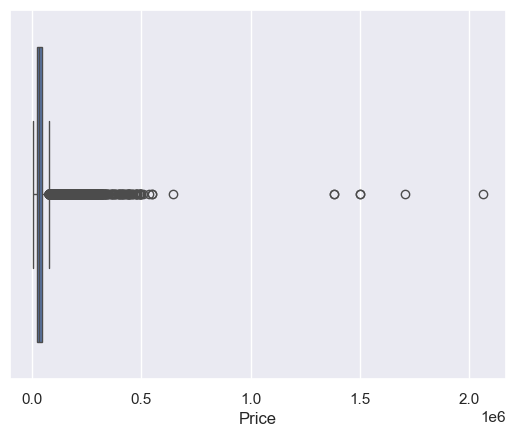

In [22]:
sns.boxplot(x=df['Price'])
plt.show()

## Observation

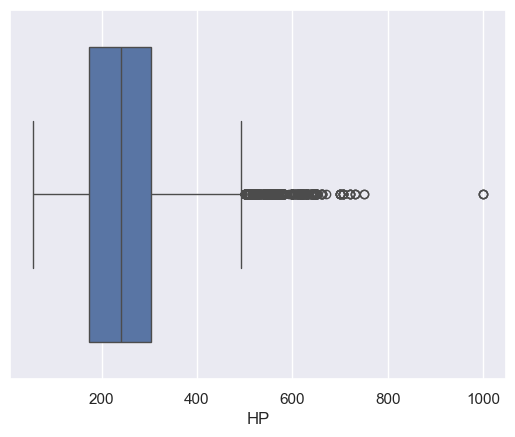

0

In [23]:
sns.boxplot(x=df['HP'])
plt.show()
0

In [24]:
print(df.loc[:, df.dtypes.isin(['int64', 'float64'])])

          HP  Cylinders
0      335.0        6.0
1      300.0        6.0
2      300.0        6.0
3      230.0        6.0
4      230.0        6.0
...      ...        ...
11909  300.0        6.0
11910  300.0        6.0
11911  300.0        6.0
11912  300.0        6.0
11913  221.0        6.0

[10827 rows x 2 columns]


## Save the column names of the above output in variable list named 'l'

In [25]:
l = df.loc[:, df.dtypes.isin(['int64', 'float64'])].columns.tolist()
print(l)

['HP', 'Cylinders']


## Outliers removal techniques - IQR Method

In [26]:
Q1 = df[l].quantile(0.25)
Q3 = df[l].quantile(0.75)
IQR = Q3 - Q1
df2 = df[~((df[l] < (Q1 - 1.5 * IQR)) | (df[l] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [27]:
print('IQR:', IQR)

IQR: HP           130.0
Cylinders      2.0
dtype: float64


In [28]:
print('Original shape:', df.shape)
print('After removing outliers:', df2.shape)

Original shape: (10827, 10)
After removing outliers: (10268, 10)


In [30]:
for i in df.columns:
    print('--------------- %s ----------------' % i)
    print(df[i].value_counts())

--------------- Make ----------------
Make
Chevrolet        1043
Ford              798
Toyota            651
Volkswagen        563
Nissan            540
Dodge             513
GMC               475
Honda             429
Cadillac          396
Mazda             392
Mercedes-Benz     340
Suzuki            338
Infiniti          326
BMW               324
Audi              320
Hyundai           254
Acura             246
Volvo             241
Subaru            229
Kia               219
Mitsubishi        202
Lexus             201
Chrysler          185
Buick             184
Pontiac           163
Lincoln           152
Porsche           134
Land Rover        126
Oldsmobile        111
Saab              101
Aston Martin       91
Bentley            74
Ferrari            69
Plymouth           62
Scion              60
FIAT               58
Maserati           55
Lamborghini        52
Rolls-Royce        31
Lotus              28
HUMMER             17
Maybach            16
McLaren             5
Alfa Romeo 

## Visualising Univariate Distributions

### Histogram & Density Plots

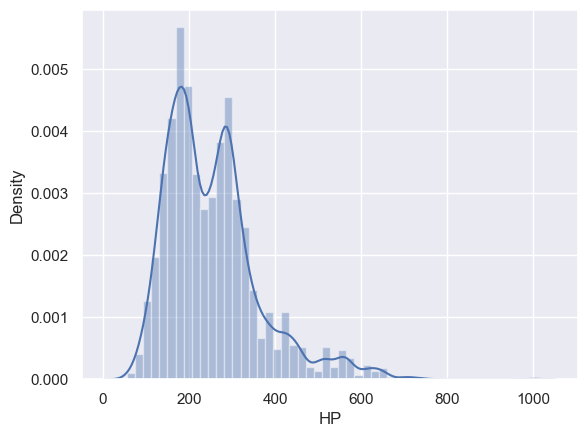

In [31]:
sns.distplot(df['HP'])
plt.show()

##   Observation

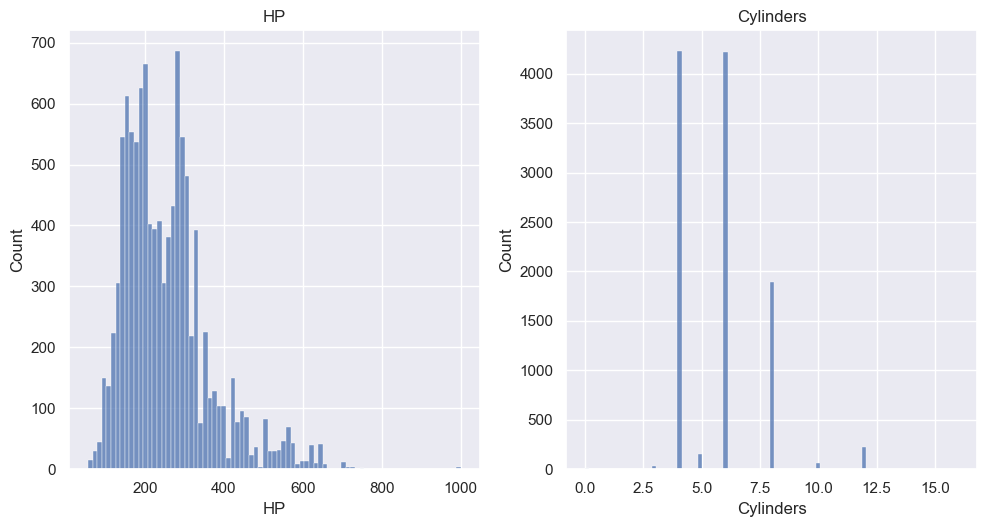

In [32]:
c = 0
plt.figure(figsize=(15, 10))
for i in l:
    c += 1
    plt.subplot(2, 3, c)
    sns.histplot(df[i])
    plt.title(i)
plt.tight_layout()
plt.show()

## Bar Chart PLots 

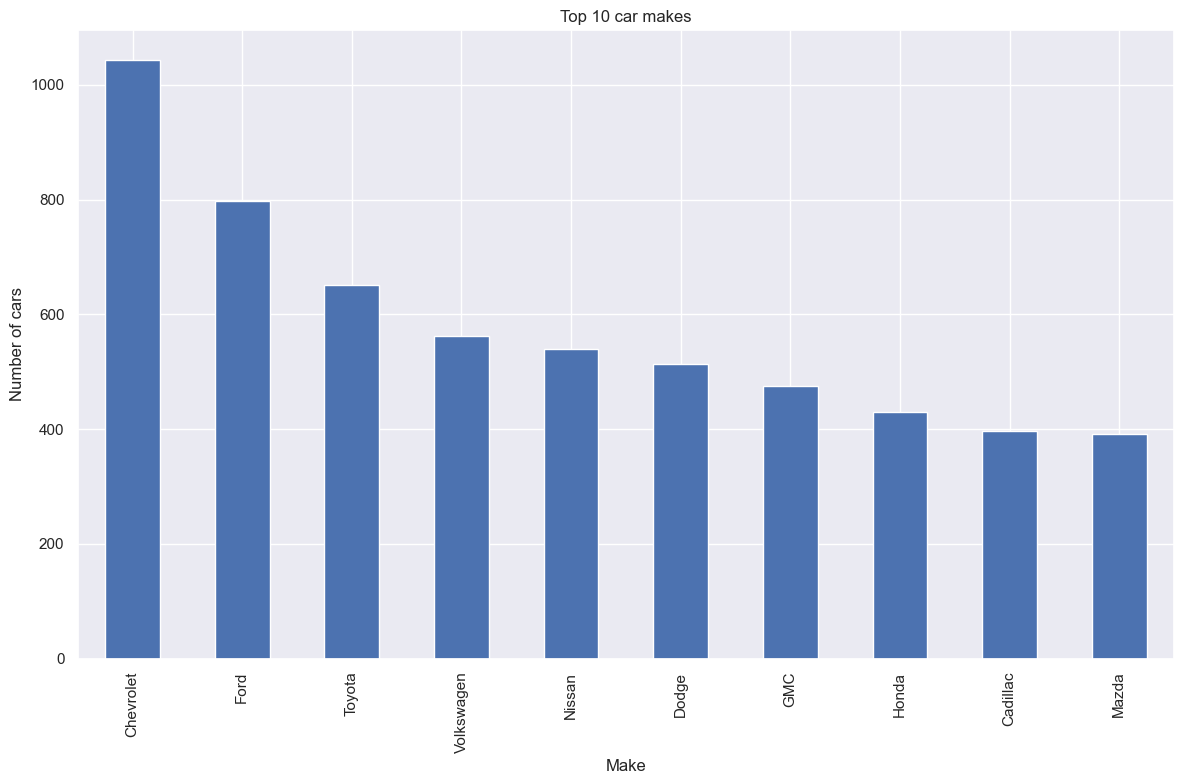

In [33]:
plt.figure(figsize=(12, 8))
df['Make'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 car makes')
plt.xlabel('Make')
plt.ylabel('Number of cars')
plt.tight_layout()
plt.show()

### Count Plot

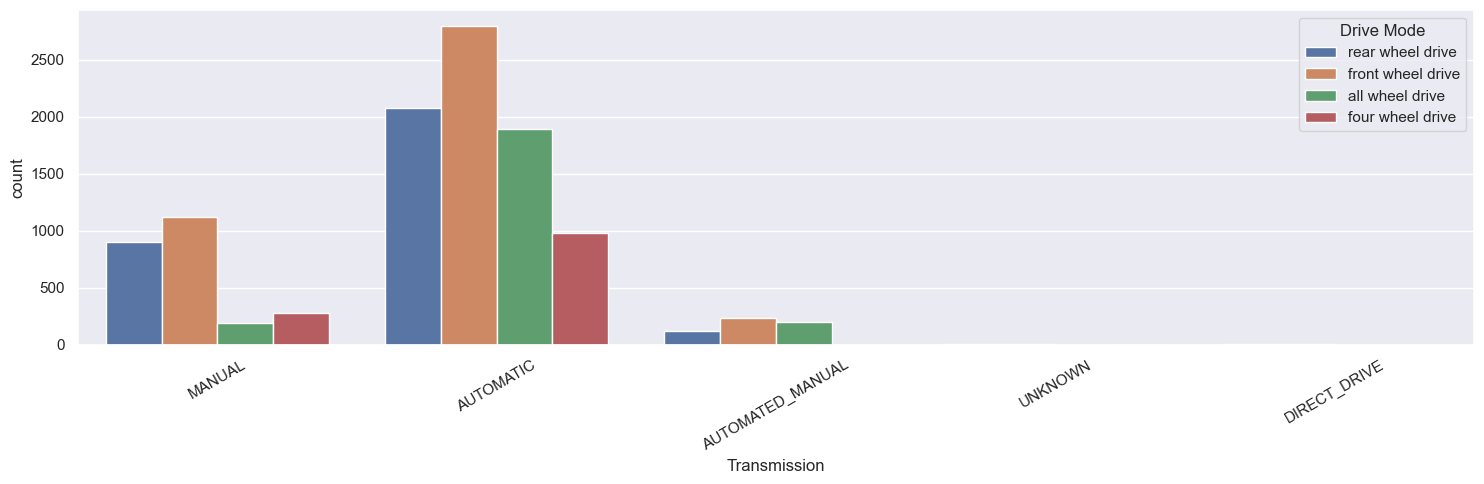

In [35]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='Transmission', hue='Drive Mode')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Visualising Bivariate Distributions

## Scatter Plots

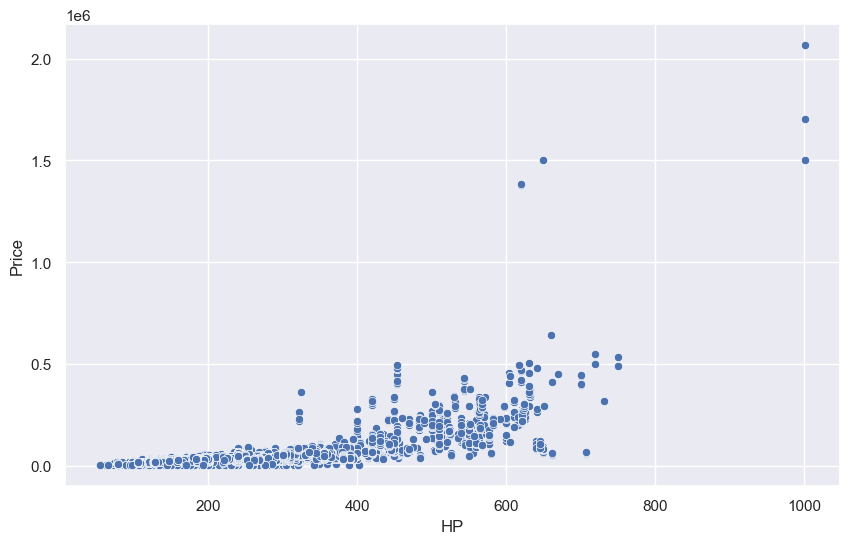

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='HP', y='Price', ax=ax)
plt.show()

## Plotting Aggregated Values across Categories


### Bar Plots - Mean, Median and Count Plots

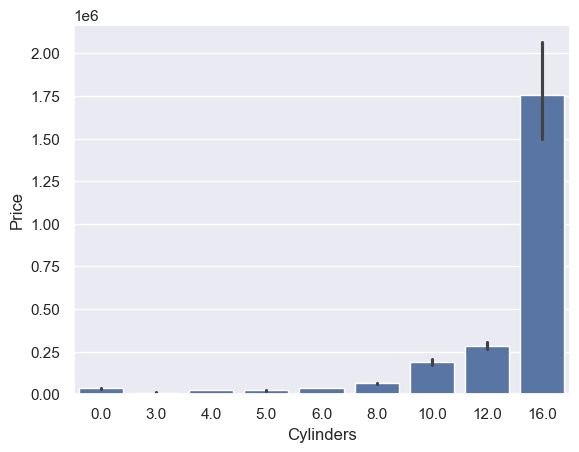

In [38]:
sns.barplot(data=df, x='Cylinders', y='Price')
plt.show()

# Plotting categorical variable Transmission across the y-axis

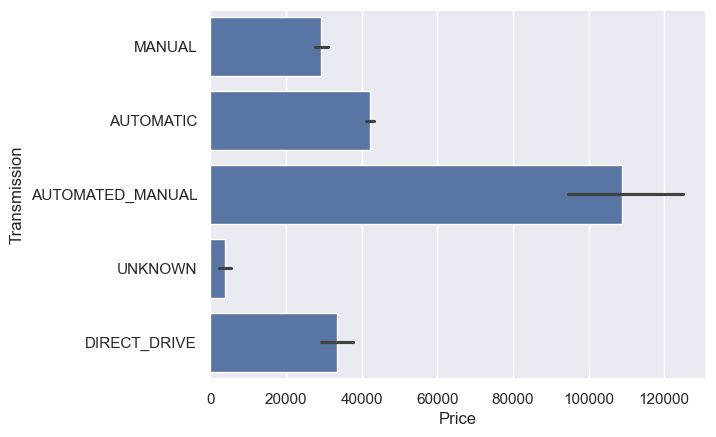

In [39]:
sns.barplot(data=df, y='Transmission', x='Price')
plt.show()

## Multivariate Plots

### Heatmaps

In [40]:
corr = df.select_dtypes(include='number').corr()
print(corr)

               Year        HP  Cylinders     MPG-H     MPG-C     Price
Year       1.000000  0.314971  -0.050598  0.284237  0.234135  0.196789
HP         0.314971  1.000000   0.788007 -0.420281 -0.473551  0.659835
Cylinders -0.050598  0.788007   1.000000 -0.611576 -0.632407  0.554740
MPG-H      0.284237 -0.420281  -0.611576  1.000000  0.841229 -0.209150
MPG-C      0.234135 -0.473551  -0.632407  0.841229  1.000000 -0.234050
Price      0.196789  0.659835   0.554740 -0.209150 -0.234050  1.000000


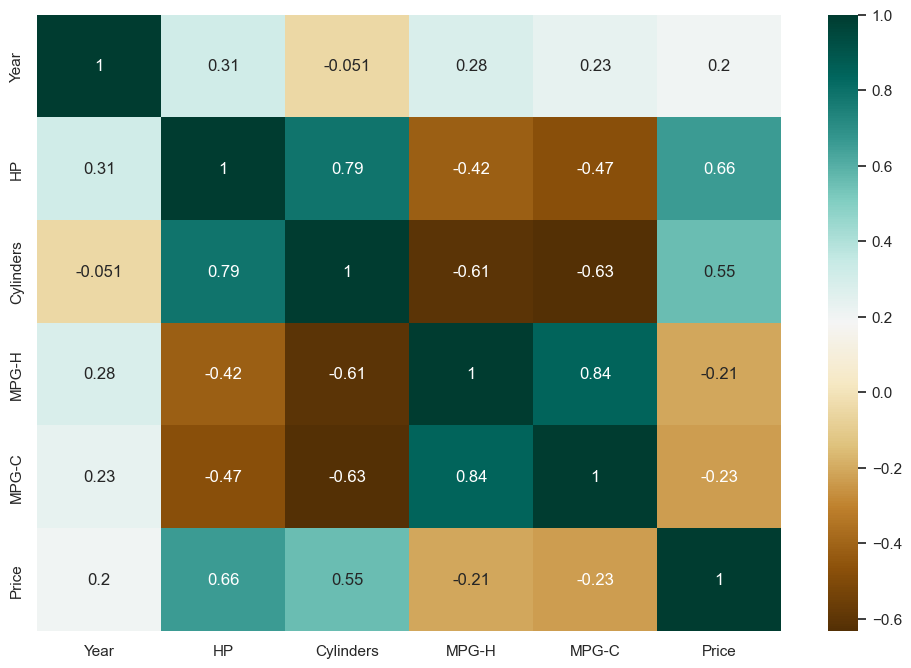

In [41]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='BrBG', annot=True)
plt.show()
